<a href="https://colab.research.google.com/github/Sanjana-Anandan/Flood_Risk_Prediction/blob/main/Fog_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import kagglehub
path = kagglehub.dataset_download("denvermagtibay/metro-manila-flood-prediction-20162020-daily")

100%|██████████| 57.4k/57.4k [00:00<00:00, 20.2MB/s]

Extracting files...


In [ ]:
import os

print(path)
print(os.listdir(path))

/root/.cache/kagglehub/datasets/denvermagtibay/metro-manila-flood-prediction-20162020-daily/versions/1
['Flood_Prediction_NCR_Philippines.csv']


In [ ]:
df = pd.read_csv(os.path.join(path, "Flood_Prediction_NCR_Philippines.csv"))

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7308 entries, 0 to 7307
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              7308 non-null   object 
 1   Location          7308 non-null   object 
 2   Rainfall_mm       7308 non-null   float64
 3   WaterLevel_m      7308 non-null   float64
 4   SoilMoisture_pct  7308 non-null   float64
 5   Elevation_m       7308 non-null   int64  
 6   FloodOccurrence   7308 non-null   int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 399.8+ KB


In [ ]:
df.describe()

,Rainfall_mm,WaterLevel_m,SoilMoisture_pct,Elevation_m,FloodOccurrence
count,7308.000000,7308.000000,7308.000000,7308.000000,7308.000000
mean,10.052874,1.266379,15.184989,17.000000,0.018062
std,7.101769,0.902239,5.994044,15.557414,0.133186
min,0.100000,0.500000,5.000000,5.000000,0.000000
25%,4.900000,0.500000,10.900000,5.000000,0.000000
50%,8.400000,1.000000,14.900000,10.000000,0.000000
75%,13.500000,1.800000,19.100000,22.000000,0.000000
max,52.700000,6.400000,39.700000,43.000000,1.000000


In [ ]:
df.head()

,Date,Location,Rainfall_mm,WaterLevel_m,SoilMoisture_pct,Elevation_m,FloodOccurrence
0,2016-01-01,Quezon City,12.0,0.5,15.3,43,0
1,2016-01-01,Marikina,10.6,1.8,23.2,15,0
2,2016-01-01,Manila,5.7,0.5,15.6,5,0
3,2016-01-01,Pasig,3.7,0.5,5.0,5,0
4,2016-01-02,Quezon City,3.4,0.5,13.3,43,0


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Location", "Date"])

df.head()

,Date,Location,Rainfall_mm,WaterLevel_m,SoilMoisture_pct,Elevation_m,FloodOccurrence
2,2016-01-01,Manila,5.7,0.5,15.6,5,0
6,2016-01-02,Manila,5.3,0.5,13.2,5,0
10,2016-01-03,Manila,2.4,0.5,12.2,5,0
14,2016-01-04,Manila,4.7,1.1,15.4,5,0
18,2016-01-05,Manila,7.9,1.8,19.0,5,0


In [ ]:
print(df["Location"].unique())
print(df["Date"].min(), "to", df["Date"].max())

['Manila' 'Marikina' 'Pasig' 'Quezon City']
2016-01-01 00:00:00 to 2020-12-31 00:00:00


In [ ]:
# rainfall accumulation
df["Rainfall_3day_sum"] = (
    df.groupby("Location")["Rainfall_mm"]
    .rolling(window=3)
    .sum()
    .reset_index(level=0, drop=True)
)

df["Rainfall_7day_sum"] = (
    df.groupby("Location")["Rainfall_mm"]
    .rolling(window=7)
    .sum()
    .reset_index(level=0, drop=True)
)

# water level mean
df["WaterLevel_3day_avg"] = (
    df.groupby("Location")["WaterLevel_m"]
    .rolling(window=3)
    .mean()
    .reset_index(level=0, drop=True)
)

# previous day flood
df["Flood_lag1"] = (
    df.groupby("Location")["FloodOccurrence"]
    .shift(1)
)

df.head(10)

,Date,Location,Rainfall_mm,WaterLevel_m,SoilMoisture_pct,Elevation_m,FloodOccurrence,Rainfall_3day_sum,Rainfall_7day_sum,WaterLevel_3day_avg,Flood_lag1
2,2016-01-01,Manila,5.7,0.5,15.6,5,0,NaN,NaN,NaN,NaN
6,2016-01-02,Manila,5.3,0.5,13.2,5,0,NaN,NaN,NaN,0.0
10,2016-01-03,Manila,2.4,0.5,12.2,5,0,13.4,NaN,0.500000,0.0
14,2016-01-04,Manila,4.7,1.1,15.4,5,0,12.4,NaN,0.700000,0.0
18,2016-01-05,Manila,7.9,1.8,19.0,5,0,15.0,NaN,1.133333,0.0
22,2016-01-06,Manila,22.0,2.0,18.4,5,0,34.6,NaN,1.633333,0.0
26,2016-01-07,Manila,6.0,0.5,5.7,5,0,35.9,54.0,1.433333,0.0
30,2016-01-08,Manila,8.7,1.3,26.7,5,0,36.7,57.0,1.266667,0.0
34,2016-01-09,Manila,3.4,2.0,8.9,5,0,18.1,55.1,1.266667,0.0
38,2016-01-10,Manila,14.8,2.8,11.2,5,0,26.9,67.5,2.033333,0.0


In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
Rainfall_mm,0
WaterLevel_m,0
SoilMoisture_pct,0
Elevation_m,0
FloodOccurrence,0
Rainfall_3day_sum,8
Rainfall_7day_sum,24
WaterLevel_3day_avg,8


In [ ]:
df = df.dropna().reset_index(drop=True)

df.shape

(7284, 11)

In [ ]:
train_df = df[df["Date"] < "2020-01-01"]
test_df = df[df["Date"] >= "2020-01-01"]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (5820, 11)
Test size: (1464, 11)


In [ ]:
train_df["FloodOccurrence"].value_counts(normalize=True)

,proportion
FloodOccurrence,
0,0.983677
1,0.016323


In [ ]:
feature_cols = [
    "Rainfall_mm",
    "WaterLevel_m",
    "SoilMoisture_pct",
    "Elevation_m",
    "Rainfall_3day_sum",
    "Rainfall_7day_sum",
    "WaterLevel_3day_avg",
    "Flood_lag1"
]

X_train = train_df[feature_cols]
y_train = train_df["FloodOccurrence"]

X_test = test_df[feature_cols]
y_test = test_df["FloodOccurrence"]

X_train.shape

(5820, 8)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1427
           1       0.74      1.00      0.85        37

    accuracy                           0.99      1464
   macro avg       0.87      1.00      0.92      1464
weighted avg       0.99      0.99      0.99      1464


Confusion Matrix:
[[1414   13]
 [   0   37]]


In [ ]:
import joblib

joblib.dump(model, "edge_flood_model.pkl")
joblib.dump(scaler, "edge_scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [ ]:
import os
os.listdir()

['.config', 'edge_scaler.pkl', 'edge_flood_model.pkl', 'sample_data']

In [ ]:
adjacency = {
    "Manila": ["Pasig"],
    "Pasig": ["Manila", "Marikina"],
    "Marikina": ["Pasig", "Quezon City"],
    "Quezon City": ["Marikina"]
}

In [ ]:
loaded_model = joblib.load("edge_flood_model.pkl")
loaded_scaler = joblib.load("edge_scaler.pkl")

In [ ]:
simulation_df = test_df.copy()
simulation_df = simulation_df.sort_values(["Date", "Location"])
simulation_df.head()

,Date,Location,Rainfall_mm,WaterLevel_m,SoilMoisture_pct,Elevation_m,FloodOccurrence,Rainfall_3day_sum,Rainfall_7day_sum,WaterLevel_3day_avg,Flood_lag1
1455,2020-01-01,Manila,8.4,3.5,15.1,5,0,41.8,103.2,2.200000,0.0
3276,2020-01-01,Marikina,6.6,0.5,9.6,15,0,46.1,75.7,0.966667,0.0
5097,2020-01-01,Pasig,3.1,0.5,17.0,5,0,44.6,87.4,0.966667,0.0
6918,2020-01-01,Quezon City,7.3,0.9,16.3,43,0,22.2,44.3,0.933333,0.0
1456,2020-01-02,Manila,11.8,0.7,18.4,5,0,43.1,111.7,2.200000,0.0


In [ ]:
simulation_results = []

In [ ]:
from collections import defaultdict

unique_dates = simulation_df["Date"].unique()

for date in unique_dates:

    daily_data = simulation_df[simulation_df["Date"] == date]

    city_predictions = {}
    flood_cities = []

    # --- EDGE NODES ---
    for _, row in daily_data.iterrows():
        city = row["Location"]

        features = row[feature_cols].values.reshape(1, -1)
        scaled_features = loaded_scaler.transform(features)

        prediction = loaded_model.predict(scaled_features)[0]

        city_predictions[city] = prediction

        if prediction == 1:
            flood_cities.append(city)

    # --- FOG LAYER ---
    regional_risk = "LOW"

    if len(flood_cities) == 1:
        regional_risk = "MODERATE"
    elif len(flood_cities) >= 2:
        regional_risk = "HIGH"

    # --- ALERT PROPAGATION ---
    propagated_alerts = defaultdict(list)

    for city in flood_cities:
        neighbors = adjacency.get(city, [])
        for neighbor in neighbors:
            propagated_alerts[neighbor].append("PRE-ALERT")

    # Store results
    simulation_results.append({
        "Date": date,
        "City_Predictions": city_predictions,
        "Flood_Cities": flood_cities,
        "Regional_Risk": regional_risk,
        "Propagated_Alerts": dict(propagated_alerts)
    })

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
simulation_results[:3]

[{'Date': Timestamp('2020-01-01 00:00:00'),
  'City_Predictions': {'Manila': np.int64(0),
   'Marikina': np.int64(0),
   'Pasig': np.int64(0),
   'Quezon City': np.int64(0)},
  'Flood_Cities': [],
  'Regional_Risk': 'LOW',
  'Propagated_Alerts': {}},
 {'Date': Timestamp('2020-01-02 00:00:00'),
  'City_Predictions': {'Manila': np.int64(0),
   'Marikina': np.int64(0),
   'Pasig': np.int64(0),
   'Quezon City': np.int64(0)},
  'Flood_Cities': [],
  'Regional_Risk': 'LOW',
  'Propagated_Alerts': {}},
 {'Date': Timestamp('2020-01-03 00:00:00'),
  'City_Predictions': {'Manila': np.int64(0),
   'Marikina': np.int64(0),
   'Pasig': np.int64(0),
   'Quezon City': np.int64(0)},
  'Flood_Cities': [],
  'Regional_Risk': 'LOW',
  'Propagated_Alerts': {}}]

In [ ]:
import pandas as pd

records = []

for entry in simulation_results:
    date = entry["Date"]
    predictions = entry["City_Predictions"]
    regional_risk = entry["Regional_Risk"]

    for city, pred in predictions.items():
        records.append({
            "Date": date,
            "City": city,
            "Flood_Predicted": pred,
            "Regional_Risk": regional_risk
        })

results_df = pd.DataFrame(records)

results_df.head()

,Date,City,Flood_Predicted,Regional_Risk
0,2020-01-01,Manila,0,LOW
1,2020-01-01,Marikina,0,LOW
2,2020-01-01,Pasig,0,LOW
3,2020-01-01,Quezon City,0,LOW
4,2020-01-02,Manila,0,LOW


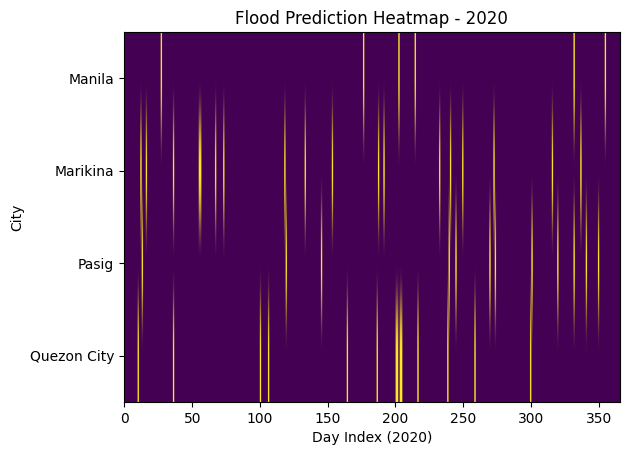

In [ ]:
import matplotlib.pyplot as plt

pivot_df = results_df.pivot(index="Date", columns="City", values="Flood_Predicted")

plt.figure()
plt.imshow(pivot_df.T, aspect="auto")
plt.xlabel("Day Index (2020)")
plt.ylabel("City")
plt.title("Flood Prediction Heatmap - 2020")
plt.yticks(range(len(pivot_df.columns)), pivot_df.columns)
plt.show()

In [ ]:
risk_map = {
    "LOW": 0,
    "MODERATE": 1,
    "HIGH": 2
}

regional_df = results_df[["Date", "Regional_Risk"]].drop_duplicates()
regional_df["Risk_Level"] = regional_df["Regional_Risk"].map(risk_map)

regional_df = regional_df.sort_values("Date")
regional_df.head()

,Date,Regional_Risk,Risk_Level
0,2020-01-01,LOW,0
4,2020-01-02,LOW,0
8,2020-01-03,LOW,0
12,2020-01-04,LOW,0
16,2020-01-05,LOW,0


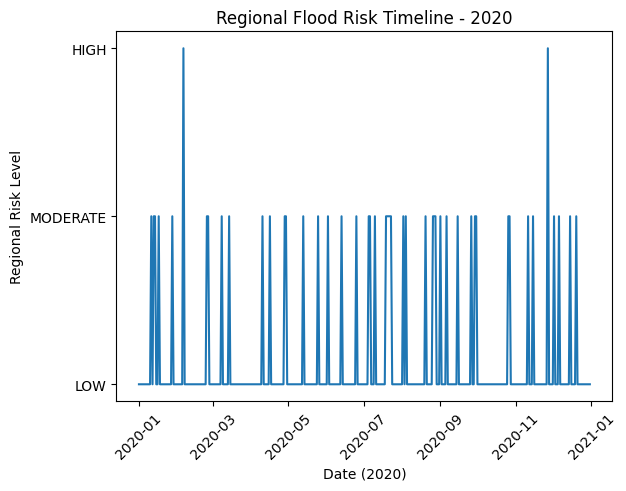

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(regional_df["Date"], regional_df["Risk_Level"])
plt.xlabel("Date (2020)")
plt.ylabel("Regional Risk Level")
plt.title("Regional Flood Risk Timeline - 2020")
plt.yticks([0, 1, 2], ["LOW", "MODERATE", "HIGH"])
plt.xticks(rotation=45)
plt.show()

In [ ]:
propagation_records = []

for entry in simulation_results:
    date = entry["Date"]
    propagated = entry["Propagated_Alerts"]

    total_prealerts = sum(len(v) for v in propagated.values())

    propagation_records.append({
        "Date": date,
        "PreAlert_Count": total_prealerts
    })

propagation_df = pd.DataFrame(propagation_records)
propagation_df.head()

,Date,PreAlert_Count
0,2020-01-01,0
1,2020-01-02,0
2,2020-01-03,0
3,2020-01-04,0
4,2020-01-05,0


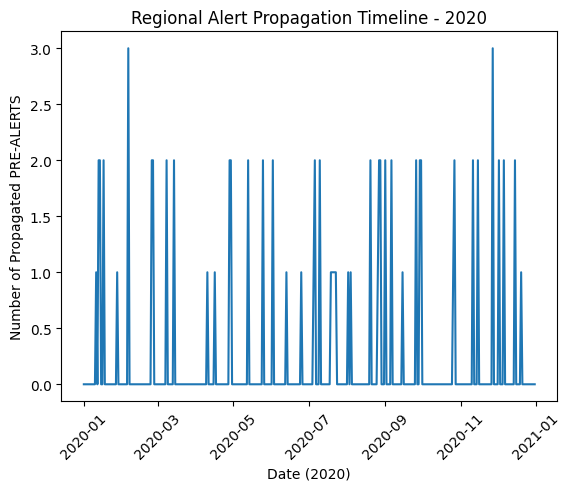

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(propagation_df["Date"], propagation_df["PreAlert_Count"])
plt.xlabel("Date (2020)")
plt.ylabel("Number of Propagated PRE-ALERTS")
plt.title("Regional Alert Propagation Timeline - 2020")
plt.xticks(rotation=45)
plt.show()

In [ ]:
sum(propagation_df["PreAlert_Count"])

80

In [ ]:
for entry in simulation_results:
    if entry["Flood_Cities"]:
        print(entry["Date"], entry["Flood_Cities"], entry["Propagated_Alerts"])

2020-01-11 00:00:00 ['Quezon City'] {'Marikina': ['PRE-ALERT']}
2020-01-13 00:00:00 ['Marikina'] {'Pasig': ['PRE-ALERT'], 'Quezon City': ['PRE-ALERT']}
2020-01-14 00:00:00 ['Pasig'] {'Manila': ['PRE-ALERT'], 'Marikina': ['PRE-ALERT']}
2020-01-17 00:00:00 ['Marikina'] {'Pasig': ['PRE-ALERT'], 'Quezon City': ['PRE-ALERT']}
2020-01-28 00:00:00 ['Manila'] {'Pasig': ['PRE-ALERT']}
2020-02-06 00:00:00 ['Marikina', 'Quezon City'] {'Pasig': ['PRE-ALERT'], 'Quezon City': ['PRE-ALERT'], 'Marikina': ['PRE-ALERT']}
2020-02-25 00:00:00 ['Marikina'] {'Pasig': ['PRE-ALERT'], 'Quezon City': ['PRE-ALERT']}
2020-02-26 00:00:00 ['Marikina'] {'Pasig': ['PRE-ALERT'], 'Quezon City': ['PRE-ALERT']}
2020-03-08 00:00:00 ['Marikina'] {'Pasig': ['PRE-ALERT'], 'Quezon City': ['PRE-ALERT']}
2020-03-14 00:00:00 ['Marikina'] {'Pasig': ['PRE-ALERT'], 'Quezon City': ['PRE-ALERT']}
2020-04-10 00:00:00 ['Quezon City'] {'Marikina': ['PRE-ALERT']}
2020-04-16 00:00:00 ['Quezon City'] {'Marikina': ['PRE-ALERT']}
2020-04-28 